<a href="https://colab.research.google.com/github/olyadiya/RecSystem_ML/blob/data-preprocessing/eda_steam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA и подготовка данных
## Загрузка и описание датасета

**Признаки**

* `appid` уникальный идентификатор игры
* `name` название игры
* `release_date` дата релиза в формате ГГГГ-ММ-ДД
* `english` поддержка английского языка: 1 — если есть
* `developer` имя разработчика (если несколько — через точку с запятой)
* `publisher` имя издателя (если несколько — через точку с запятой)
* `platforms` поддерживаемые платформы через точку с запятой (windows;mac;linux)
* `required_age` минимальный возраст по PEGI (0 — рейтинг не присвоен)
* `categories` категории игры через точку с запятой (single-player;multi-player)
* `genres` жанры игры через точку с запятой (action;adventure)
* `steamspy_tags` теги с сайта SteamSpy (выбранные игроками) через точку с запятой
* `achievements` количество ачивок в игре
* `positive_ratings` количество положительных отзывов (из SteamSpy)
* `negative_ratings` количество отрицательных отзывов (из SteamSpy)
* `average_playtime` среднее время игры в минутах (из SteamSpy)
* `median_playtime` медианное время игры в минутах (из SteamSpy)
* `owners` количество человек, купивших игру в Steam (нижняя и верхняя граница, например 20000-50000)
* `price` цена в фунтах стерлингов

## Загрузка датасета и базовый анализ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
df_orig = pd.read_csv("/content/steam.csv")

In [3]:
df = df_orig.copy()
df.head(5)

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [4]:
# Базовый анализ
print("Размер датасета:", df_orig.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())
print("\nУникальные значения в колонках с множественными значениями:")
print(f"Categories: {df['categories'].nunique()} уникальных комбинаций")
print(f"Genres: {df['genres'].nunique()} уникальных комбинаций")
print(f"Steamspy_tags: {df['steamspy_tags'].nunique()} уникальных комбинаций")

Размер датасета: (27075, 18)

Типы данных:
appid                 int64
name                 object
release_date         object
english               int64
developer            object
publisher            object
platforms            object
required_age          int64
categories           object
genres               object
steamspy_tags        object
achievements          int64
positive_ratings      int64
negative_ratings      int64
average_playtime      int64
median_playtime       int64
owners               object
price               float64
dtype: object

Пропуски:
appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64



# Признаки

## Создание `release_year`

In [5]:
df['release_year'] = df['release_date'].str[:4].astype(int)
df

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,release_year
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19,2000
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99,1999
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99,2003
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99,2001
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99,1999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27070,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,windows,0,Single-player;Steam Achievements,Adventure;Casual;Indie,Adventure;Indie;Casual,7,3,0,0,0,0-20000,2.09,2019
27071,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,windows,0,Single-player,Action;Adventure;Indie,Action;Indie;Adventure,0,8,1,0,0,0-20000,1.69,2019
27072,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,windows,0,Single-player;Multi-player;Co-op;Shared/Split ...,Action;Casual;Indie,Action;Indie;Casual,24,0,1,0,0,0-20000,3.99,2019
27073,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,2,0,0,0,0-20000,5.19,2019


## Анализ `developer` и `publisher`

In [6]:
df['developer'] = df['developer'].fillna('Unknown')
df['publisher'] = df['publisher'].fillna('Unknown')

In [7]:
same = (df['developer'] == df['publisher']).sum()
print(f"Совпадают developer и publisher: {same} из {len(df)} игр ({same/len(df)*100:.1f}%)")

unique_pairs = df.groupby(['developer', 'publisher']).size().reset_index(name='count')
print(f"\nУникальных пар (developer, publisher): {len(unique_pairs)}")

print("\nТоп-10 пар (developer >>> publisher):")
print(unique_pairs.sort_values('count', ascending=False).head(10))

Совпадают developer и publisher: 17592 из 27075 игр (65.0%)

Уникальных пар (developer, publisher): 18269

Топ-10 пар (developer >>> publisher):
                        developer                   publisher  count
2804              Choice of Games             Choice of Games     94
8003   KOEI TECMO GAMES CO., LTD.  KOEI TECMO GAMES CO., LTD.     69
12683             Ripknot Systems             Ripknot Systems     62
10520          Nikita "Ghost_RUS"             Ghost_RUS Games     50
8547     Laush Dmitriy Sergeevich                Laush Studio     47
4010                 Dexion Games                Dexion Games     45
12630                   RewindApp                   RewindApp     43
6918                 Hosted Games                Hosted Games     42
1996                Blender Games               Blender Games     40
5478                     For Kids                    For Kids     36


In [ ]:
cross_tab = pd.crosstab(df['developer'], df['publisher'])

chi2, p, dof, expected = chi2_contingency(cross_tab)
n = cross_tab.sum().sum()

cramers_v = np.sqrt(chi2 / (n * (min(cross_tab.shape) - 1)))

print(f"\nКорреляция Крамера между developer и publisher: {cramers_v:.3f}")


Корреляция Крамера между developer и publisher: 0.978


Корреляция, как и ожидалось, очень высокая (0.978), при этом в 65% случаев разработчик и издатель - одна и та же компания.

In [8]:
dev_counts = df['developer'].value_counts()

dev_more_than_5 = dev_counts[dev_counts > 5]
print(f"Разработчиков с > 2 игр: {len(dev_more_than_5)}")

dev_more_than_5 = dev_counts[dev_counts > 5]
print(f"Разработчиков с > 5 игр: {len(dev_more_than_5)}")

dev_more_than_10 = dev_counts[dev_counts > 10]
print(f"Разработчиков с > 10 игр: {len(dev_more_than_10)}")

dev_more_than_20 = dev_counts[dev_counts > 20]
print(f"Разработчиков с > 20 игр: {len(dev_more_than_20)}")

print("\nТоп-20 разработчиков по количеству игр:")
print(dev_counts.head(20))

Разработчиков с > 2 игр: 457
Разработчиков с > 5 игр: 457
Разработчиков с > 10 игр: 143
Разработчиков с > 20 игр: 36

Топ-20 разработчиков по количеству игр:
developer
Choice of Games               94
KOEI TECMO GAMES CO., LTD.    72
Ripknot Systems               62
Laush Dmitriy Sergeevich      51
Nikita "Ghost_RUS"            50
Dexion Games                  45
RewindApp                     43
Hosted Games                  42
Blender Games                 40
For Kids                      36
Humongous Entertainment       36
EnsenaSoft                    35
Nekyau Games                  32
Eipix Entertainment           32
Warfare Studios               31
HeR Interactive               30
MumboJumbo                    29
ERS G Studios                 28
Creobit                       28
HexWar Games                  27
Name: count, dtype: int64


Выявлено, что распределение игр по разработчикам крайне неравномерно. Всего 457 разработчиков имеют более двух игр, из них лишь 143 - более десяти, и только 36 - более двадцати. При этом топ-20 разработчиков представлен преимущественно малоизвестными инди-студиями, выпускающими большое количество небольших проектов.

## Создание `rating_ratio`

In [9]:
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
df['rating_ratio'] = df['positive_ratings'] / (df['total_ratings'] + 1)
df['rating_ratio']

,rating_ratio
0,0.973881
1,0.839575
2,0.895413
3,0.826087
4,0.947825
...,...
27070,0.750000
27071,0.800000
27072,0.000000
27073,0.666667


## Создание `owners_mean`

In [10]:
def parse_owners(owners_str):
    """
    Преобразует строку вида диапазон значений через "-" в среднее.
    """
    try:
        low, high = owners_str.split('-')
        low = int(low.replace(',', ''))
        high = int(high.replace(',', ''))
        return (low + high) / 2
    except:
        return None

df['owners_mean'] = df['owners'].apply(parse_owners)
df['owners_mean']

,owners_mean
0,15000000.0
1,7500000.0
2,7500000.0
3,7500000.0
4,7500000.0
...,...
27070,10000.0
27071,10000.0
27072,10000.0
27073,10000.0


## Анализ `categories`, `genres`, `steamspy_tags`, `platforms` на отдельные признаки


In [11]:
def analyze_multivalue_column(df, col_name, top_n=10):
    """Анализирует колонку с множественными значениями"""
    # Разбиваем на отдельные значения
    all_values = []
    for val in df[col_name].dropna():
        if isinstance(val, str):
            all_values.extend([v.strip().lower() for v in val.split(';')])

    # Считаем частоту
    value_counts = pd.Series(all_values).value_counts()

    print(f"\n--- {col_name} ---")
    print(f"Всего уникальных значений: {len(value_counts)}")
    print(f"Среднее количество на игру: {df[col_name].str.split(';').str.len().mean():.2f}")

    return value_counts

# Анализируем каждое поле
categories_counts = analyze_multivalue_column(df, 'categories')
genres_counts = analyze_multivalue_column(df, 'genres')
tags_counts = analyze_multivalue_column(df, 'steamspy_tags')


--- categories ---
Всего уникальных значений: 29
Среднее количество на игру: 3.31

--- genres ---
Всего уникальных значений: 29
Среднее количество на игру: 2.82

--- steamspy_tags ---
Всего уникальных значений: 339
Среднее количество на игру: 2.88


In [12]:
def get_set(col):
    s = set()
    for x in df[col].dropna():
        for v in str(x).split(';'):
            s.add(v.strip())
    return s

genres = get_set('genres')
cats = get_set('categories')
tags = get_set('steamspy_tags')
platforms = get_set('platforms')

print(f'Жанров: {len(genres)}')
print(f'Категорий: {len(cats)}')
print(f'Тегов: {len(tags)}')
print(f'Платформ: {len(platforms)}')
print()

print(f'Жанры в тегах: {len(genres & tags)} из {len(genres)}')
print(f'Платформы в тегах: {len(platforms & tags)} из {len(platforms)}')
print(f'Категории в тегах: {len(cats & tags)} из {len(cats)}')

Жанров: 29
Категорий: 29
Тегов: 339
Платформ: 3

Жанры в тегах: 27 из 29
Платформы в тегах: 0 из 3
Категории в тегах: 1 из 29


# Визуализации

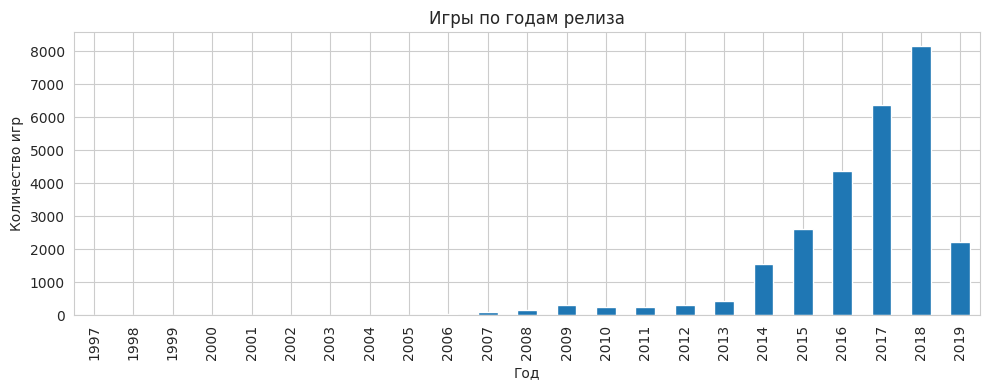

In [13]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

# 1. ГОДЫ РЕЛИЗА
df['release_year'] = df['release_date'].str[:4].astype(int)

plt.figure()
df['release_year'].value_counts().sort_index().plot(kind='bar')
plt.title('Игры по годам релиза')
plt.xlabel('Год')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

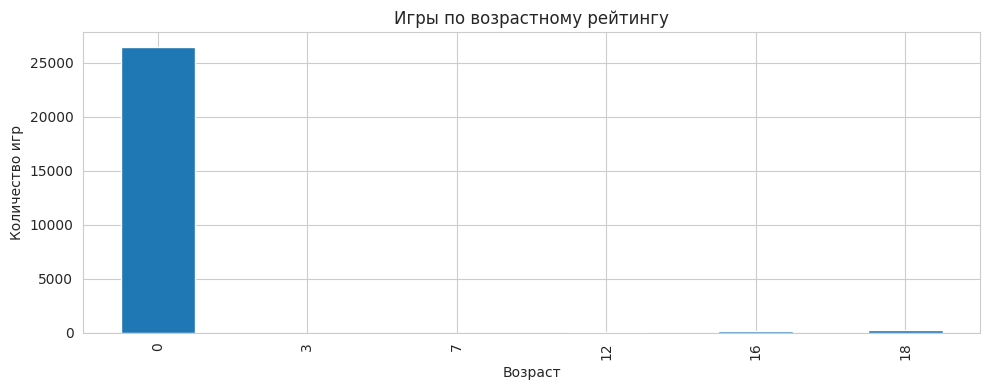

In [14]:
# 2. ВОЗРАСТ
plt.figure()
df['required_age'].value_counts().sort_index().plot(kind='bar')
plt.title('Игры по возрастному рейтингу')
plt.xlabel('Возраст')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

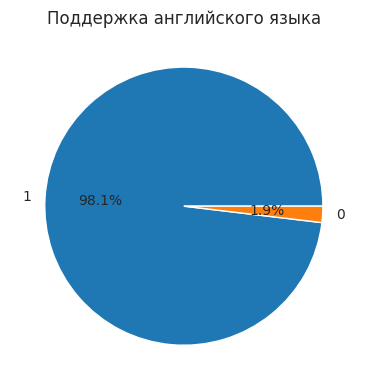

In [15]:
# 3. ПОДДЕРЖКА АНГЛИЙСКОГО
plt.figure()
df['english'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Поддержка английского языка')
plt.ylabel('')
plt.tight_layout()
plt.show()

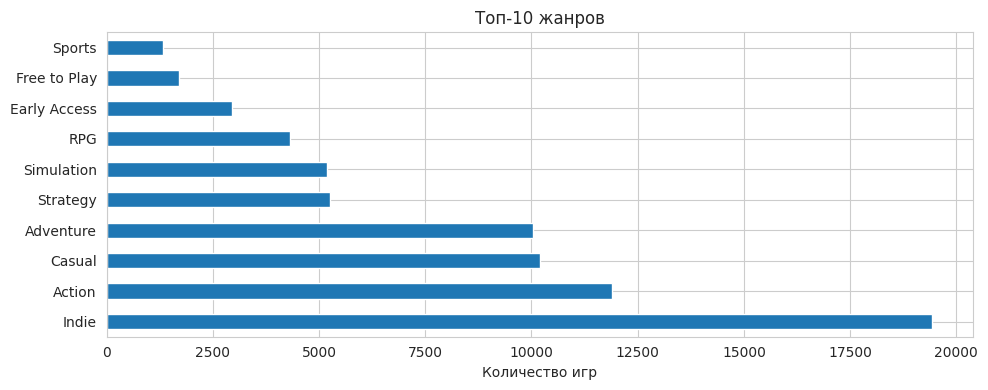

In [16]:
# 4. ЖАНРЫ (топ-10)
genres_flat = []
for val in df['genres'].dropna():
    genres_flat.extend([v.strip() for v in val.split(';')])
genres_counts = pd.Series(genres_flat).value_counts().head(10)

plt.figure()
genres_counts.plot(kind='barh')
plt.title('Топ-10 жанров')
plt.xlabel('Количество игр')
plt.tight_layout()
plt.show()

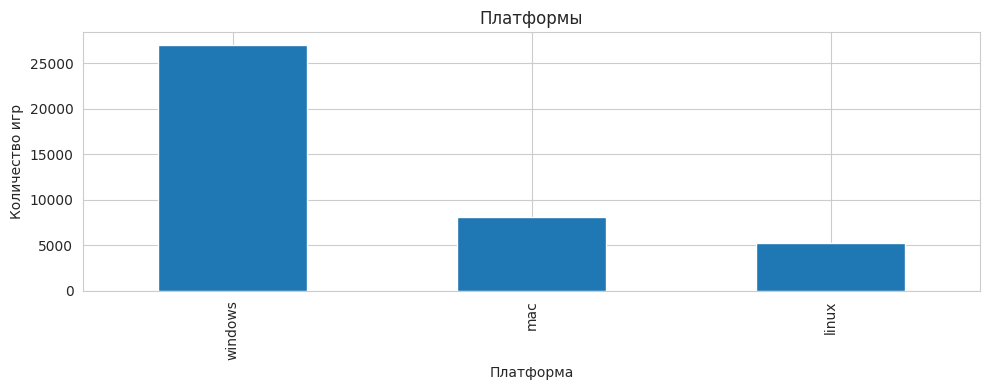

In [17]:
# 5. ПЛАТФОРМЫ
platforms_flat = []
for val in df['platforms'].dropna():
    platforms_flat.extend([v.strip() for v in val.split(';')])
platforms_counts = pd.Series(platforms_flat).value_counts()

plt.figure()
platforms_counts.plot(kind='bar')
plt.title('Платформы')
plt.xlabel('Платформа')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

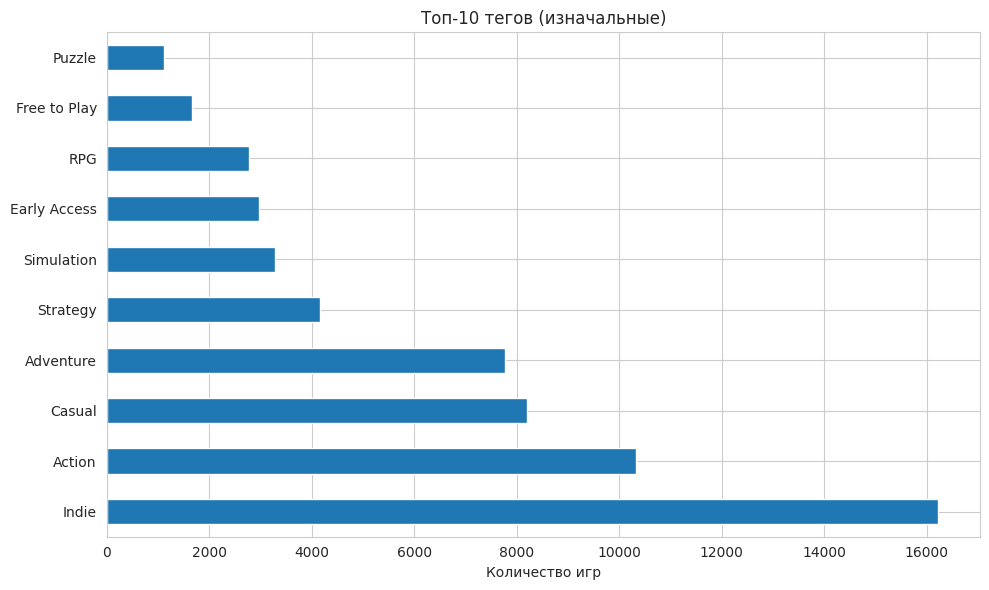

In [18]:
# 6. ТЕГИ (топ-10; изначальные, неочищенные)
tags_flat = []
for val in df['steamspy_tags'].dropna():
    tags_flat.extend([v.strip() for v in val.split(';')])

tags_counts = pd.Series(tags_flat).value_counts().head(10)

plt.figure(figsize=(10, 6))
tags_counts.plot(kind='barh')
plt.title('Топ-10 тегов (изначальные)')
plt.xlabel('Количество игр')
plt.tight_layout()
plt.show()

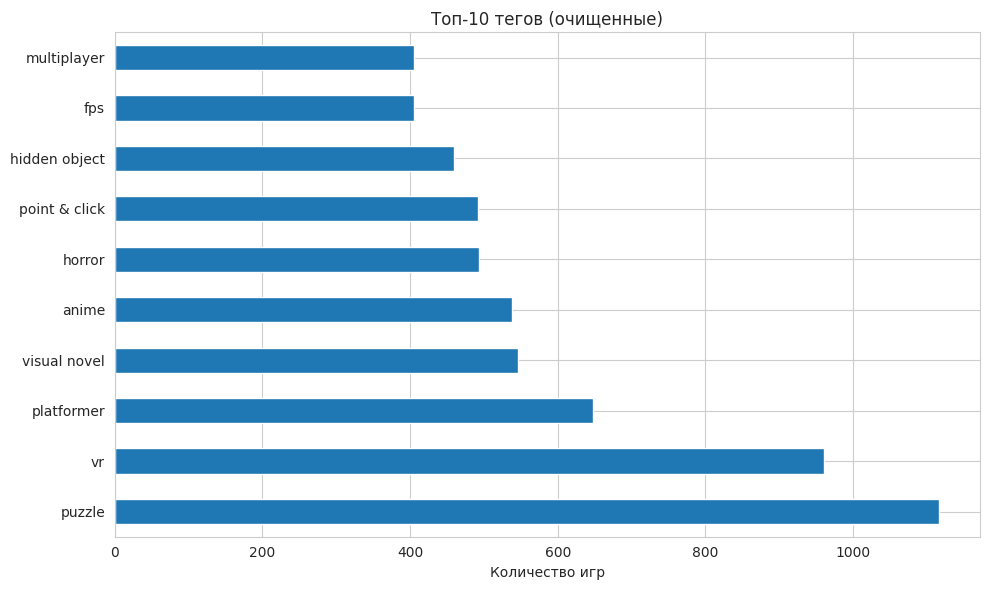

In [19]:
# 7. ТЕГИ (очищенные от того, что есть в genres и categories)

all_genres = []
for val in df['genres'].dropna():
    if isinstance(val, str):
        all_genres.extend([v.strip().lower() for v in val.split(';')])

all_categories = []
for val in df['categories'].dropna():
    if isinstance(val, str):
        all_categories.extend([v.strip().lower() for v in val.split(';')])

tags_clean = []
for val in df['steamspy_tags'].dropna():
    if isinstance(val, str):
        for v in val.split(';'):
            v_clean = v.strip().lower()
            if v_clean not in all_genres and v_clean not in all_categories:
                tags_clean.append(v_clean)

tags_counts = pd.Series(tags_clean).value_counts()

plt.figure(figsize=(10, 6))
tags_counts.head(10).plot(kind='barh')
plt.title('Топ-10 тегов (очищенные)')
plt.xlabel('Количество игр')
plt.tight_layout()
plt.show()

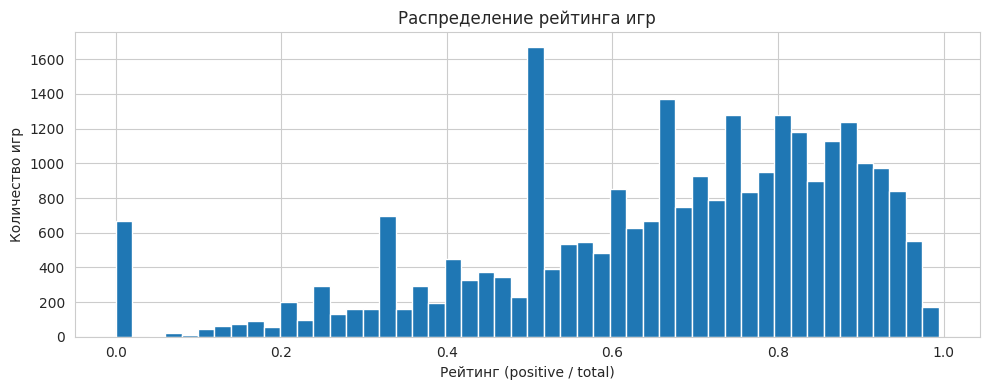

In [20]:
# 8. РЕЙТИНГ
plt.figure()
df['rating_ratio'].hist(bins=50)
plt.title('Распределение рейтинга игр')
plt.xlabel('Рейтинг (positive / total)')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

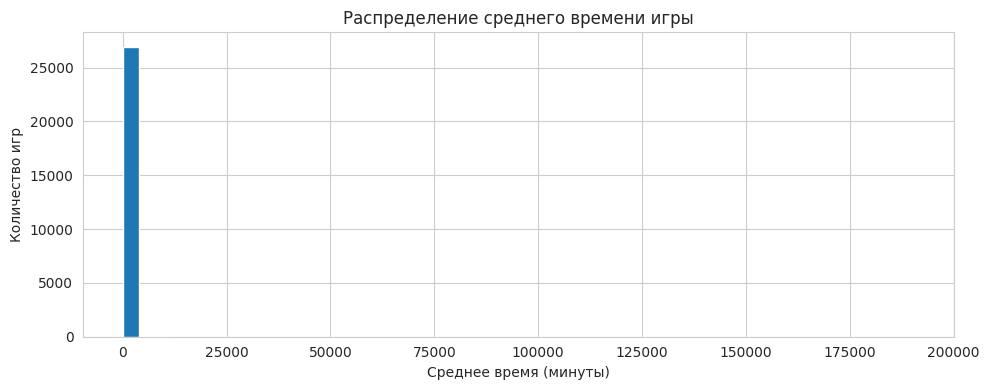

In [21]:
# 9. ВРЕМЯ ИГРЫ
plt.figure()
df['average_playtime'].hist(bins=50)
plt.title('Распределение среднего времени игры')
plt.xlabel('Среднее время (минуты)')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

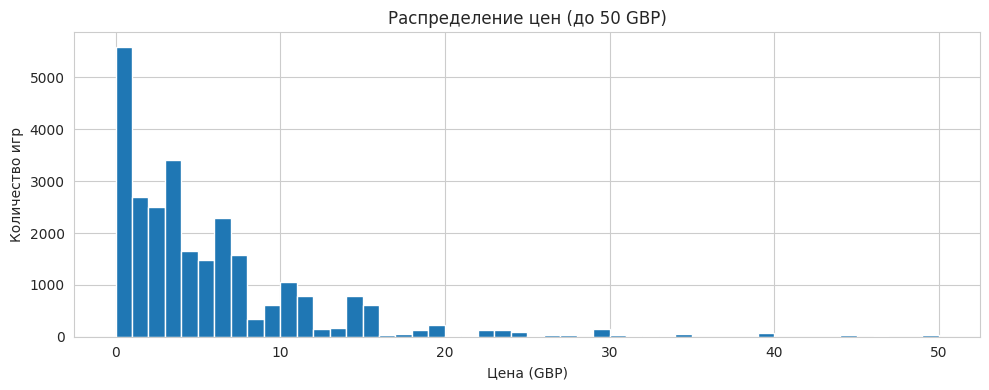

In [22]:
# 10. ЦЕНА
plt.figure()
df[df['price'] < 50]['price'].hist(bins=50)
plt.title('Распределение цен (до 50 GBP)')
plt.xlabel('Цена (GBP)')
plt.ylabel('Количество игр')
plt.tight_layout()
plt.show()

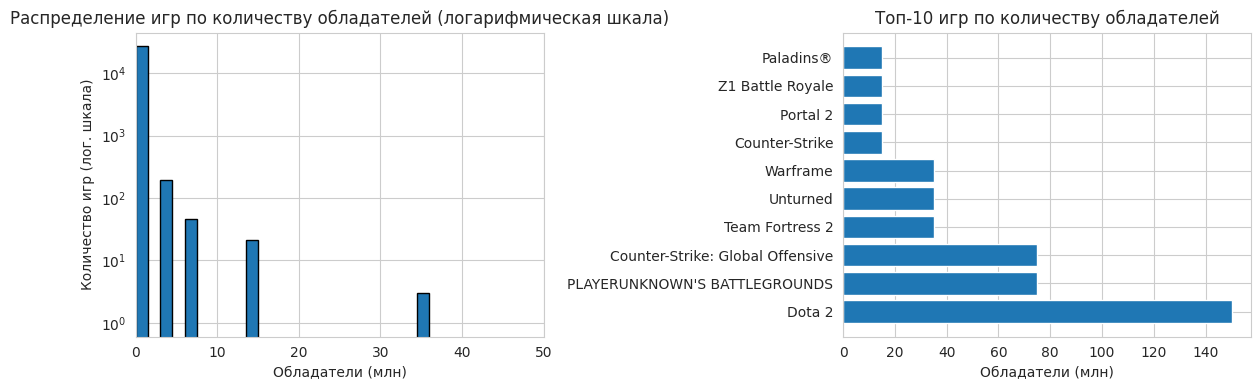

In [29]:
# 11.1 ОБЩЕЕ РАСПРЕДЕЛЕНИЕ ИГР ПО КОЛИЧЕСТВУ ОБЛАДАТЕЛЕЙ (логарифмическая шкала)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['owners_mean'] / 1_000_000, bins=100, edgecolor='black', log=True)
plt.title('Распределение игр по количеству обладателей (логарифмическая шкала)')
plt.xlabel('Обладатели (млн)')
plt.ylabel('Количество игр (лог. шкала)')
plt.xlim(0, 50)

# 11.2 ТОП-10 ПО ОБЛАДАТЕЛЯМ
plt.subplot(1, 2, 2)
top_owners = df.sort_values('owners_mean', ascending=False).head(10)[['name', 'owners_mean']]
plt.barh(top_owners['name'], top_owners['owners_mean'] / 1_000_000)
plt.title('Топ-10 игр по количеству обладателей')
plt.xlabel('Обладатели (млн)')

plt.tight_layout()
plt.show()

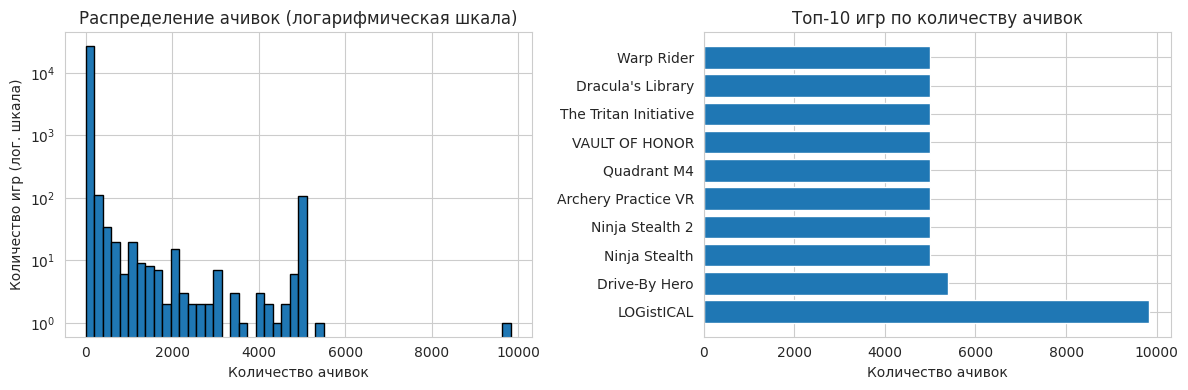

In [31]:
plt.figure(figsize=(12, 4))

# 12.1 ОБЩЕЕ РАСПРЕДЕЛЕНИЕ АЧИВОК (логарифмическая шкала)
plt.subplot(1, 2, 1)
df['achievements'].hist(bins=50, edgecolor='black', log=True)
plt.title('Распределение ачивок (логарифмическая шкала)')
plt.xlabel('Количество ачивок')
plt.ylabel('Количество игр (лог. шкала)')

# 12.2 ТОП-10 ПО АЧИВКАМ
plt.subplot(1, 2, 2)
top_achievements = df.nlargest(10, 'achievements')[['name', 'achievements']]
plt.barh(top_achievements['name'], top_achievements['achievements'])
plt.title('Топ-10 игр по количеству ачивок')
plt.xlabel('Количество ачивок')

plt.tight_layout()
plt.show()

Возрастной рейтинг - почти все 0, нет вариативности.

Почти все игры поддерживают английский - нет вариативности.

Среднее время игры - 0, нет данных.